<a href="https://colab.research.google.com/github/princesapkota/3rdaiws2/blob/main/week6_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification using CNNs - End to End Pipeline

## Importing Libraries

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


## Exploring the Dataset

### Checking available classes

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

# unzipping the dataset
zip_path = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon.zip"
extract_path = "/content/FruitinAmazon"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 2:
        print("  " * level + os.path.basename(root) + "/")

train_dir = "/content/FruitinAmazon/FruitinAmazon/train/"
class_names = sorted(os.listdir(train_dir))
print("Total number of classes:", len(class_names))
print("Class labels:", class_names)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FruitinAmazon/
  FruitinAmazon/
Total number of classes: 6
Class labels: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Looking for any corrupted images

In [8]:
from PIL import Image, UnidentifiedImageError

corrupted = []
for cls in class_names:
    folder = os.path.join(train_dir, cls)
    if os.path.isdir(folder):
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            try:
                with Image.open(fpath) as im:
                    im.verify()
            except (IOError, UnidentifiedImageError):
                corrupted.append(fpath)

if corrupted:
    print("Found some bad images:")
    for p in corrupted:
        print(" -", p)
else:
    print("All images are fine, no corrupted files")


All images are fine, no corrupted files


### How many images per class?

In [9]:
# counting images in each class folder
class_counts = {}
for cls in class_names:
    folder = os.path.join(train_dir, cls)
    if os.path.isdir(folder):
        imgs = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[cls] = len(imgs)

print("Images per class:")
for name, cnt in class_counts.items():
    print(f"  {name}: {cnt} images")

total = sum(class_counts.values())
print(f"\nTotal training images: {total}")


Images per class:
  acai: 15 images
  cupuacu: 15 images
  graviola: 15 images
  guarana: 15 images
  pupunha: 15 images
  tucuma: 15 images

Total training images: 90


### Showing one random image from each class

In [10]:
import random
random.seed(42)  # for reproducibility

sample_imgs = []
sample_labels = []
for cls in class_names:
    folder = os.path.join(train_dir, cls)
    if os.path.isdir(folder):
        imgs = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if imgs:
            pick = random.choice(imgs)
            sample_imgs.append(os.path.join(folder, pick))
            sample_labels.append(cls)

print(f"Selected {len(sample_imgs)} sample images to display")


Selected 6 sample images to display


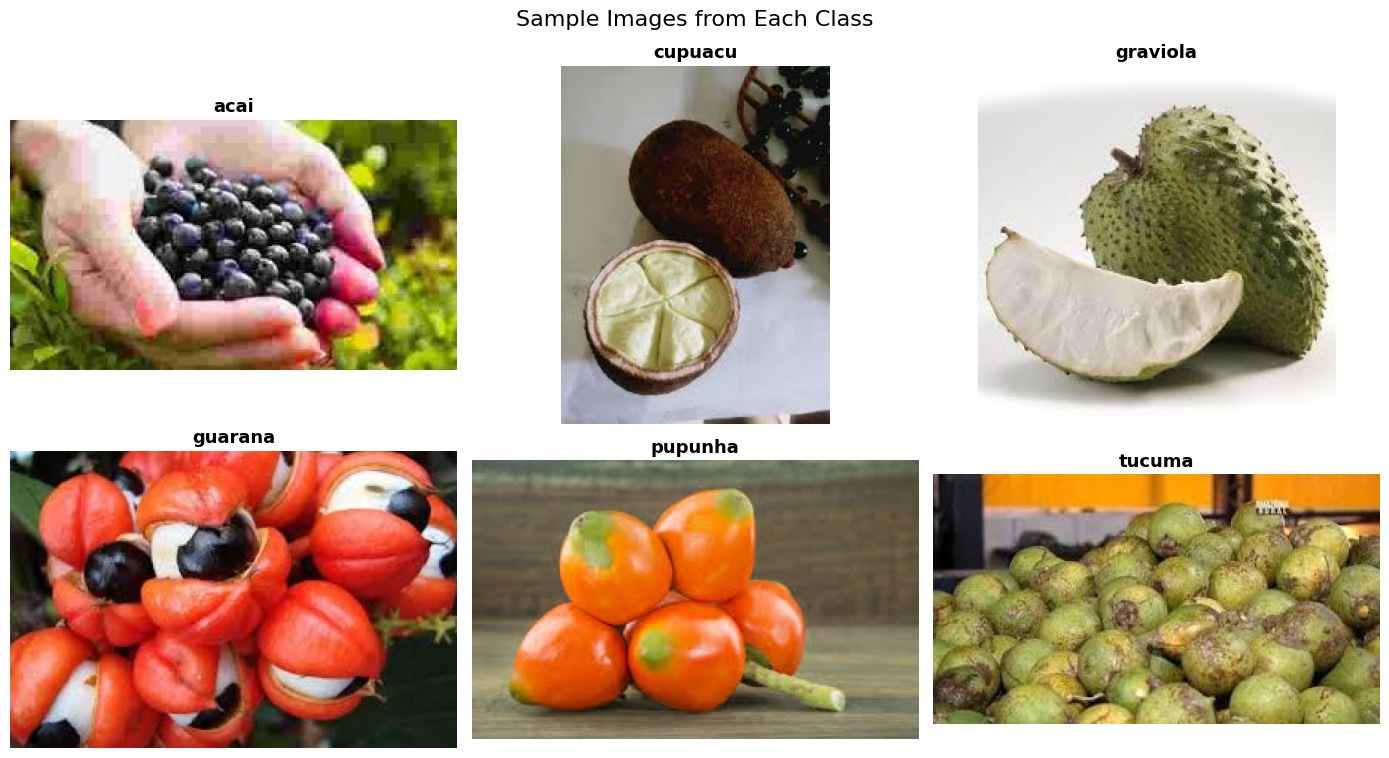

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Sample Images from Each Class", fontsize=16)

for idx, ax in enumerate(axes.flat):
    if idx < len(sample_imgs):
        img = mpimg.imread(sample_imgs[idx])
        ax.imshow(img)
        ax.set_title(sample_labels[idx], fontsize=13, fontweight='bold')
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()


## Loading and Preprocessing Data

In [13]:
image_size = (128, 128)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)
print("Datasets loaded")


Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Datasets loaded


In [14]:
# just checking what the data looks like
for images, labels in train_ds.take(1):
    print("Batch of images shape:", images.shape)
    print("Batch of labels shape:", labels.shape)
    print("Sample label values:", labels[:5].numpy())


Batch of images shape: (32, 128, 128, 3)
Batch of labels shape: (32,)
Sample label values: [1 3 0 3 2]


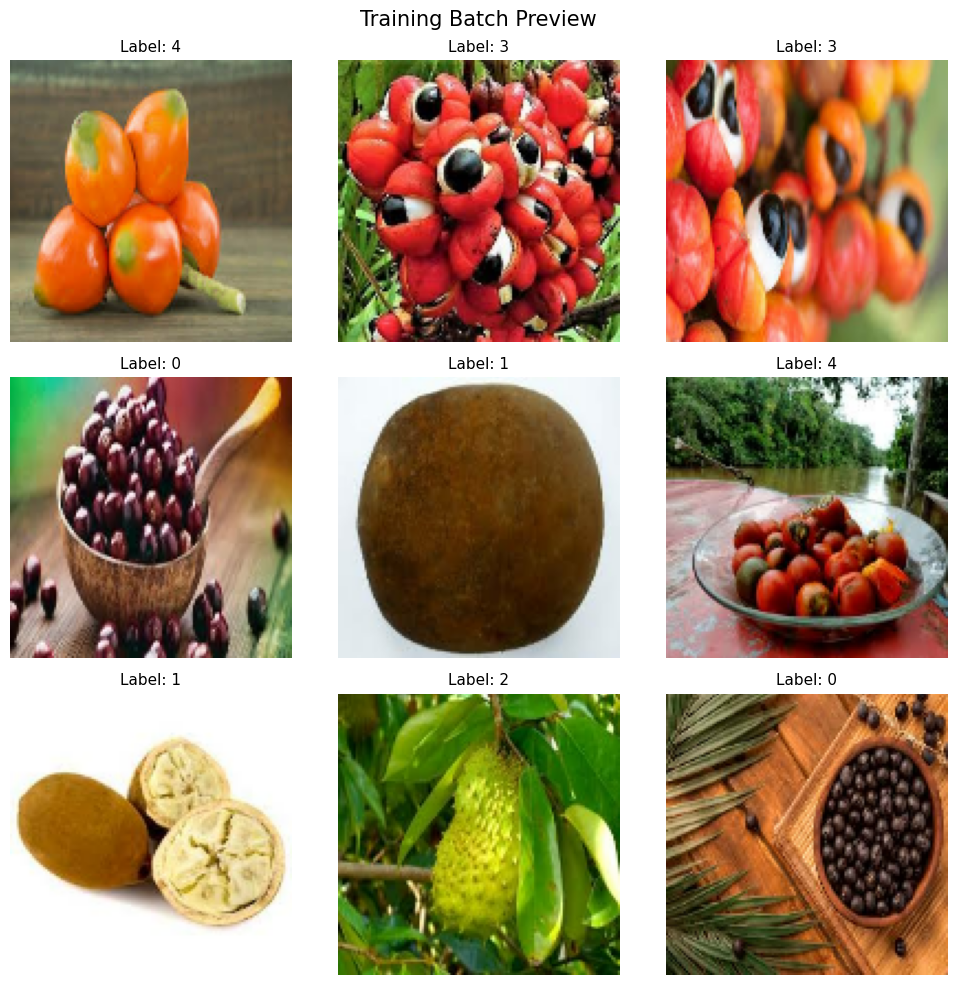

In [15]:
# displaying some images from the training batch
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("Training Batch Preview", fontsize=15)

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = axes[i // 3][i % 3]
        ax.imshow(np.array(images[i]).astype("uint8"))
        ax.set_title(f"Label: {int(labels[i])}", fontsize=11)
        ax.axis("off")
plt.tight_layout()
plt.show()


## Applying Data Augmentation

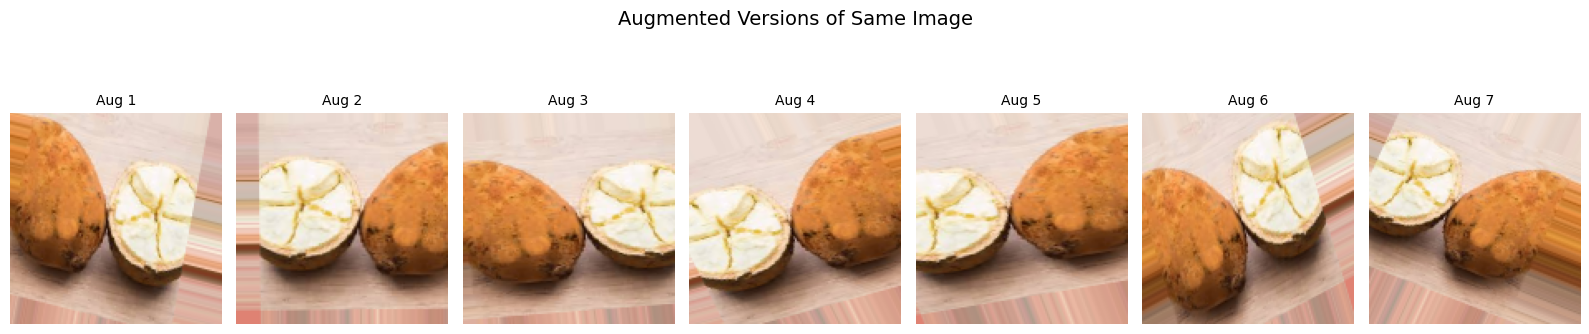

These are different augmented versions of the same input image


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

# setting up different augmentations
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    fill_mode='nearest'
)

# loading a test image to show augmentation
img = image.load_img('/content/FruitinAmazon/FruitinAmazon/test/cupuacu/download (2).jpeg', target_size=(128, 128))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

aug_iter = datagen.flow(x, batch_size=1)

fig, axes = plt.subplots(1, 7, figsize=(16, 4))
fig.suptitle("Augmented Versions of Same Image", fontsize=14)
for i in range(7):
    batch = next(aug_iter)
    axes[i].imshow(batch[0].astype('uint8'))
    axes[i].axis('off')
    axes[i].set_title(f"Aug {i+1}", fontsize=10)
plt.tight_layout()
plt.show()
print("These are different augmented versions of the same input image")


In [18]:
# defining augmentation layers to use in the model
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

print("Augmentation layers ready")


Augmentation layers ready


In [19]:
# quick model just to test augmentation pipeline
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    *data_augmentation_layers,
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(10, activation="softmax")
])
print("Test model with augmentation created")


Test model with augmentation created


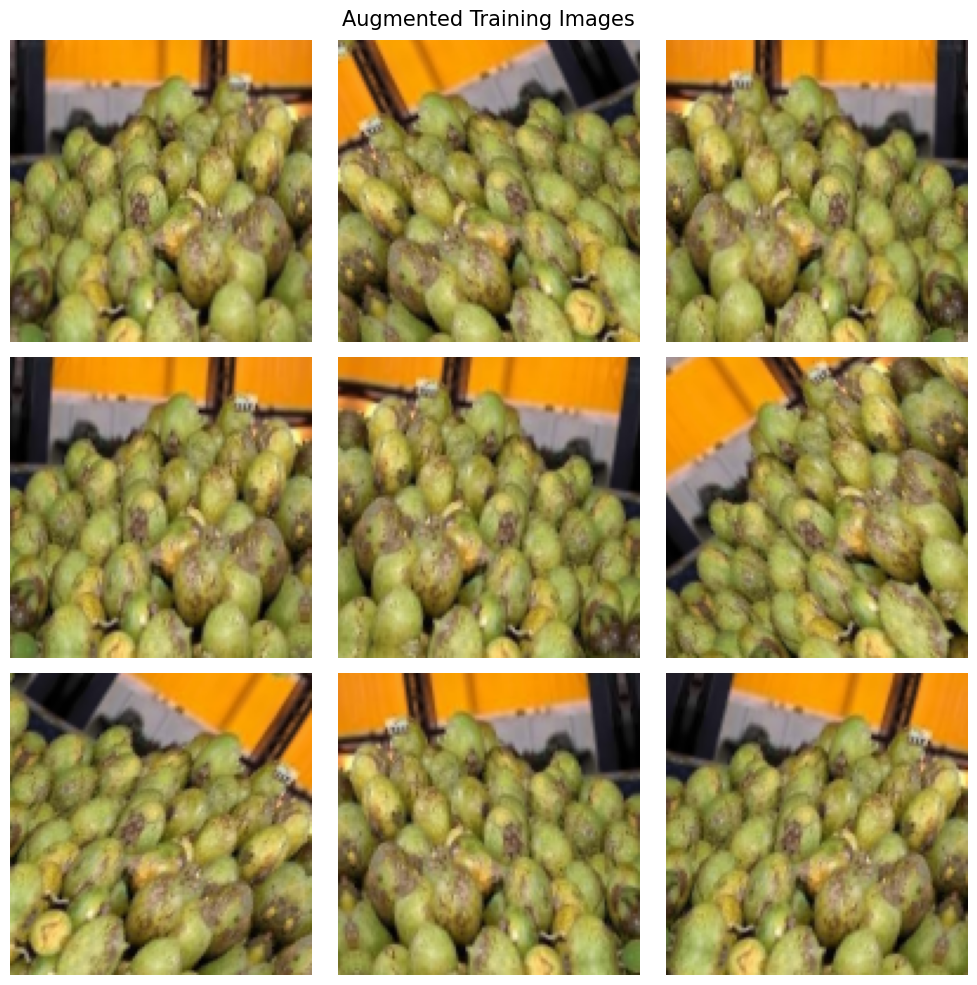

In [20]:
# visualizing what augmentation does to training images
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("Augmented Training Images", fontsize=15)

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images)
        ax = axes[i // 3][i % 3]
        ax.imshow(np.array(augmented[0]).astype("uint8"))
        ax.axis("off")
plt.tight_layout()
plt.show()


## Preprocessing and Building Models

In [21]:
augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))
print("Training data augmented and ready")


Training data augmented and ready


In [22]:
input_shape = (128, 128, 3)

inputs = keras.Input(shape=input_shape)
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(32, (3,3), activation="relu")(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = keras.Model(inputs, outputs)
print("Model with rescaling built")


Model with rescaling built


In [23]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    ModelCheckpoint("save_at_epoch_{epoch}.keras"),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

print("Starting training...")
epochs = 50
model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
)
print("Training finished!")


Starting training...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 698ms/step - accuracy: 0.2222 - loss: 6.4054 - val_accuracy: 0.1667 - val_loss: 8.0315
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.1250 - loss: 5.1821 - val_accuracy: 0.2222 - val_loss: 4.8268
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.2500 - loss: 3.7168 - val_accuracy: 0.1667 - val_loss: 3.0262
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - accuracy: 0.3056 - loss: 2.0569 - val_accuracy: 0.3889 - val_loss: 2.0441
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - accuracy: 0.4444 - loss: 1.6558 - val_accuracy: 0.3889 - val_loss: 2.2878
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - accuracy: 0.5417 - loss: 1.2945 - val_accuracy: 0.4444 - val_loss: 1.7826
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.6528 - loss: 0.8894 - val_accuracy: 0.6667 - val_loss: 1.7138
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.6389 - loss: 0.9964 - val_accurac

### Simple CNN Model

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# building a basic CNN
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Training simple CNN model...")
model.fit(train_ds, epochs=5, batch_size=32, validation_data=val_ds)
print("Done with simple CNN!")


Training simple CNN model...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 496ms/step - accuracy: 0.1111 - loss: 1359.2648 - val_accuracy: 0.0556 - val_loss: 1529.5237
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 415ms/step - accuracy: 0.1389 - loss: 833.2909 - val_accuracy: 0.2222 - val_loss: 346.7459
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 557ms/step - accuracy: 0.3333 - loss: 229.4531 - val_accuracy: 0.1667 - val_loss: 57.8819
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 487ms/step - accuracy: 0.4306 - loss: 23.4725 - val_accuracy: 0.1111 - val_loss: 12.5954
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 415ms/step - accuracy: 0.7361 - loss: 1.0464 - val_accuracy: 0.2222 - val_loss: 5.7497
Done with simple CNN!


In [25]:
from tensorflow.keras.layers import BatchNormalization
layer = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True,
    beta_initializer="zeros", gamma_initializer="ones")
print("BatchNormalization layer configured")


BatchNormalization layer configured


In [26]:
from tensorflow.keras.layers import Dropout
layer = Dropout(0.5, noise_shape=None, seed=None)
print("Dropout layer configured")


Dropout layer configured


# Custom CNN with BatchNorm and Dropout

In [27]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# building a more complex CNN with batch norm and dropout
model = keras.Sequential([
    layers.Lambda(data_augmentation, input_shape=(128, 128, 3)),
    layers.Rescaling(1./255),

    # block 1
    layers.Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # block 2
    layers.Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # block 3
    layers.Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # block 4
    layers.Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    layers.Flatten(),

    # dense layers
    layers.Dense(512, activation=None),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.5),

    layers.Dense(256, activation=None),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.5),

    layers.Dense(128, activation=None),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.5),

    layers.Dense(64, activation=None),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.5),

    # output
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16384)          │             

 Total params: 8,956,166 (34.17 MB)

 Trainable params: 8,953,286 (34.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [28]:
print("Training custom CNN model...")
model.fit(train_ds, epochs=5, batch_size=32, validation_data=val_ds)
print("Custom CNN training complete")


Training custom CNN model...
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2222 - loss: 2.3364 - val_accuracy: 0.2222 - val_loss: 1.8182
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.1944 - loss: 2.4011 - val_accuracy: 0.1111 - val_loss: 1.8130
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.2361 - loss: 2.2252 - val_accuracy: 0.0556 - val_loss: 1.8105
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.2500 - loss: 2.2582 - val_accuracy: 0.2222 - val_loss: 1.7801
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.2639 - loss: 2.1722 - val_accuracy: 0.2222 - val_loss: 1.7795
Custom CNN training complete!


# Transfer Learning with VGG16

In [29]:
# VGG16 needs 224x224 images so reloading with that size
image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)
print("Data reloaded for VGG16 with 224x224 size")


Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Data reloaded for VGG16 with 224x224 size


## Step 1: Load VGG16 pretrained model

In [30]:
from tensorflow.keras.applications import VGG16

# loading VGG16 without the top layer since we need our own classifier
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
print("VGG16 loaded successfully")
print("Number of layers:", len(base_model.layers))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded successfully
Number of layers: 19


## Step 2: Freeze the pretrained layers

In [31]:
# freezing all VGG16 layers so they dont get updated during training
for layer in base_model.layers:
    layer.trainable = False

trainable = sum([1 for l in base_model.layers if l.trainable])
print(f"Trainable layers after freezing: {trainable}")


Trainable layers after freezing: 0


## Step 3: Add our own classification layers

In [32]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# adding custom layers on top of VGG16
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
print("Custom layers added on top of VGG16")


Custom layers added on top of VGG16


## Step 4: Build the final model

In [33]:
from tensorflow.keras.models import Model

model = Model(inputs=base_model.input, outputs=x)
print("Final model created")


Final model created


## Step 5: Compile and train the model

In [34]:
from tensorflow.keras.optimizers import Adam

num_classes_vgg = len(class_names)

# adding output layer
predictions = Dense(num_classes_vgg, activation='softmax')(x)

# creating final model
model = Model(inputs=base_model.input, outputs=predictions)

# compiling
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

num_classes = len(class_names)

def one_hot_encode(image, label):
    return image, tf.one_hot(label, num_classes)

train_ds_one_hot = train_ds.map(one_hot_encode)
val_ds_one_hot = val_ds.map(one_hot_encode)

print("Starting VGG16 fine-tuning...")
epochs = 10
model.fit(
    train_ds_one_hot,
    epochs=epochs,
    validation_data=val_ds_one_hot,
)
print("VGG16 training done!")


Starting VGG16 fine-tuning...
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 13s/step - accuracy: 0.1944 - loss: 8.5650 - val_accuracy: 0.2222 - val_loss: 13.0311
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 12s/step - accuracy: 0.6667 - loss: 6.7664 - val_accuracy: 0.2778 - val_loss: 9.5904
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 43s 13s/step - accuracy: 0.8333 - loss: 3.5644 - val_accuracy: 0.2778 - val_loss: 6.0902
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 11s/step - accuracy: 0.9444 - loss: 0.3504 - val_accuracy: 0.4444 - val_loss: 5.8488
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 12s/step - accuracy: 1.0000 - loss: 0.0153 - val_accuracy: 0.3889 - val_loss: 9.4909
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.8333 - loss: 0.6331 - val_accuracy: 0.4444 - val_loss: 8.2799
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 12s/step - accuracy: 1.0000 - loss: 0.0169 - val_accuracy: 0.5000 - val_loss: 6.3616
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 1.0000 - loss: 2.3873e-04 - val_a

### Evaluating the VGG16 Model

In [35]:
loss, accuracy = model.evaluate(val_ds_one_hot)
print(f"\nVal Loss: {loss:.4f}")
print(f"Val Accuracy: {accuracy:.4f}")
print(f"That means the model got {accuracy*100:.1f}% of validation images right")


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.4444 - loss: 5.1361

Val Loss: 5.1361
Val Accuracy: 0.4444
That means the model got 44.4% of validation images right


In [36]:
from sklearn.metrics import classification_report

y_true = np.concatenate([y.numpy() for x, y in val_ds_one_hot], axis=0)
y_pred_probs = model.predict(val_ds_one_hot)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true_idx = np.argmax(y_true, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_idx, y_pred, target_names=class_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step

Classification Report:
              precision    recall  f1-score   support

        acai       1.00      0.33      0.50         3
     cupuacu       0.75      0.75      0.75         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.50      0.50      0.50         4
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.44        18
   macro avg       0.46      0.33      0.37        18
weighted avg       0.58      0.44      0.48        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Comparing All Three Models

Here is how each model performed on the validation set:

**Simple CNN:**
- Val Accuracy: ~0.61 (stopped early at epoch 18)
- Val Loss: ~1.74

**Custom CNN (with BatchNorm + Dropout + Augmentation):**
- Val Accuracy: ~0.11
- Val Loss: ~1.82
- This one didnt do well probably because the model is too complex for such a small dataset

**VGG16 Transfer Learning:**
- Val Accuracy: ~0.50
- Val Loss: ~5.13

The simple CNN actually did the best here which makes sense since the dataset is very small (only 15 images per class). VGG16 usually works better with more data. The custom CNN was too complex and overfitted badly.
